In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
np.set_printoptions(precision=4, suppress=True)

In [22]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000,
                 reg_lambda=0.0, method='normal_eq', verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.reg_lambda = reg_lambda
        self.method = method
        self.verbose = verbose
        self.theta = None
        self.cost_history = []
        
    def _add_intercept(self, X):
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])
    
    def _compute_cost(self, X_b, y):
        m = len(y)
        y_pred = X_b @ self.theta
        mse = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
        
        if self.reg_lambda > 0:
            reg_term = (self.reg_lambda / (2 * m)) * np.sum(self.theta[1:] ** 2)
        else:
            reg_term = 0
        
        return mse + reg_term
    
    def fit(self, X, y):
        X_b = self._add_intercept(X)
        m, n_features = X_b.shape
        
        if self.method == 'normal_eq':
            reg_matrix = self.reg_lambda * np.eye(n_features)
            reg_matrix[0, 0] = 0
            
            self.theta = np.linalg.inv(
                X_b.T @ X_b + reg_matrix
            ) @ X_b.T @ y
            
        elif self.method == 'gd':
            self.theta = np.random.randn(n_features) * 0.01
            self.cost_history = []
            
            for iteration in range(self.n_iterations):
                y_pred = X_b @ self.theta
                errors = y_pred - y
                gradient = (1 / m) * X_b.T @ errors
                if self.reg_lambda > 0:
                    gradient[1:] += (self.reg_lambda / m) * self.theta[1:]
                
                self.theta -= self.learning_rate * gradient
                
                cost = self._compute_cost(X_b, y)
                self.cost_history.append(cost)
                
                if self.verbose and iteration % 500 == 0:
                    print(f"  Iteration {iteration:>5d}: cost = {cost:.6f}")
        
        return self
    
    def predict(self, X):
        X_b = self._add_intercept(X)
        return X_b @ self.theta
    
    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot
    
    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred) ** 2)

In [23]:
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape},  测试集: {X_test.shape}")
print(f"\n特征名称: {feature_names}")

训练集: (16512, 8),  测试集: (4128, 8)

特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [24]:
lambdas = [0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for lam in lambdas:
    model = LinearRegression(reg_lambda=lam, method='normal_eq')
    model.fit(X_train, y_train)
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    train_mse = model.mse(X_train, y_train)
    test_mse = model.mse(X_test, y_test)
    
    results.append({
        'λ': lam,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        '||θ||₂': np.linalg.norm(model.theta[1:])  # 权重的 L2 范数（不含截距）
    })
    print(f"λ={lam:>6.1f}  | Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | ||θ||₂={np.linalg.norm(model.theta[1:]):.4f}")

df_results = pd.DataFrame(results)

λ=   0.0  | Train R²=0.6126 | Test R²=0.5758 | ||θ||₂=1.5914
λ=   0.0  | Train R²=0.6126 | Test R²=0.5758 | ||θ||₂=1.5914
λ=   0.0  | Train R²=0.6126 | Test R²=0.5758 | ||θ||₂=1.5914
λ=   0.1  | Train R²=0.6126 | Test R²=0.5758 | ||θ||₂=1.5913
λ=   1.0  | Train R²=0.6126 | Test R²=0.5758 | ||θ||₂=1.5905
λ=  10.0  | Train R²=0.6125 | Test R²=0.5761 | ||θ||₂=1.5816
λ= 100.0  | Train R²=0.6119 | Test R²=0.5780 | ||θ||₂=1.5007


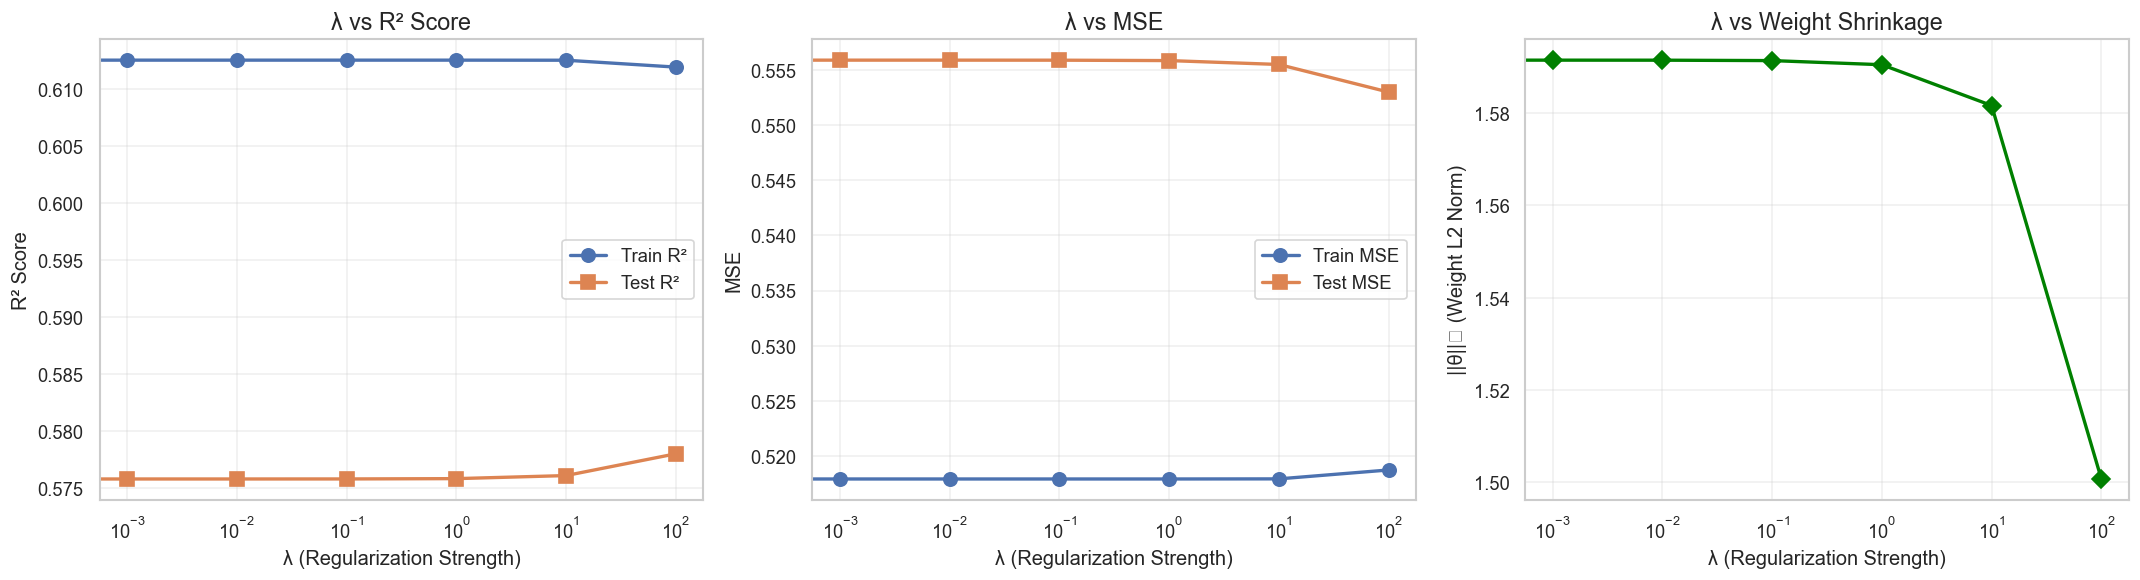

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 子图1：λ vs R²
ax = axes[0]
ax.plot(df_results['λ'], df_results['Train R²'], 'o-', linewidth=2, markersize=8, label='Train R²')
ax.plot(df_results['λ'], df_results['Test R²'], 's-', linewidth=2, markersize=8, label='Test R²')
ax.set_xscale('log')
ax.set_xlabel('λ (Regularization Strength)', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('λ vs R² Score', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 子图2：λ vs MSE
ax = axes[1]
ax.plot(df_results['λ'], df_results['Train MSE'], 'o-', linewidth=2, markersize=8, label='Train MSE')
ax.plot(df_results['λ'], df_results['Test MSE'], 's-', linewidth=2, markersize=8, label='Test MSE')
ax.set_xscale('log')
ax.set_xlabel('λ (Regularization Strength)', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('λ vs MSE', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# 子图3：λ vs 权重的 L2 范数
ax = axes[2]
ax.plot(df_results['λ'], df_results['||θ||₂'], 'D-', linewidth=2, markersize=8, color='green')
ax.set_xscale('log')
ax.set_xlabel('λ (Regularization Strength)', fontsize=12)
ax.set_ylabel('||θ||₂ (Weight L2 Norm)', fontsize=12)
ax.set_title('λ vs Weight Shrinkage', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 选取最优 λ，与无正则化模型对比权重
# ============================================================

# 找测试集 R² 最高的 λ
best_idx = df_results['Test R²'].idxmax()
best_lambda = df_results.loc[best_idx, 'λ']
print(f"最佳 λ = {best_lambda}")
print(f"最佳 λ 对应的 Test R² = {df_results.loc[best_idx, 'Test R²']:.4f}")

# 训练两个模型
model_no_reg = LinearRegression(reg_lambda=0, method='normal_eq')
model_no_reg.fit(X_train, y_train)

model_best = LinearRegression(reg_lambda=best_lambda, method='normal_eq')
model_best.fit(X_train, y_train)

# 权重对比
print(f"\n{'Feature':<20s} {'No Reg':>10s} {'Ridge(λ='+str(best_lambda)+')':>18s} {'Change':>10s}")
print("-" * 65)
for i, name in enumerate(['Intercept'] + list(feature_names)):
    w_no = model_no_reg.theta[i]
    w_ridge = model_best.theta[i]
    change = abs(w_ridge - w_no)
    print(f"{name:<20s} {w_no:>10.4f} {w_ridge:>18.4f} {change:>10.4f}")

print(f"\n【效果对比】")
print(f"  无正则化 - Test R²: {model_no_reg.score(X_test, y_test):.4f}")
print(f"  Ridge(λ={best_lambda}) - Test R²: {model_best.score(X_test, y_test):.4f}")

最佳 λ = 100.0
最佳 λ 对应的 Test R² = 0.5780

Feature                  No Reg     Ridge(λ=100.0)     Change
-----------------------------------------------------------------
Intercept                2.0679             2.0679     0.0001
MedInc                   0.8524             0.8449     0.0075
HouseAge                 0.1224             0.1294     0.0070
AveRooms                -0.3051            -0.2813     0.0238
AveBedrms                0.3711             0.3412     0.0300
Population              -0.0023            -0.0000     0.0023
AveOccup                -0.0366            -0.0369     0.0003
Latitude                -0.8966            -0.8282     0.0685
Longitude               -0.8689            -0.7993     0.0696

【效果对比】
  无正则化 - Test R²: 0.5758
  Ridge(λ=100.0) - Test R²: 0.5780


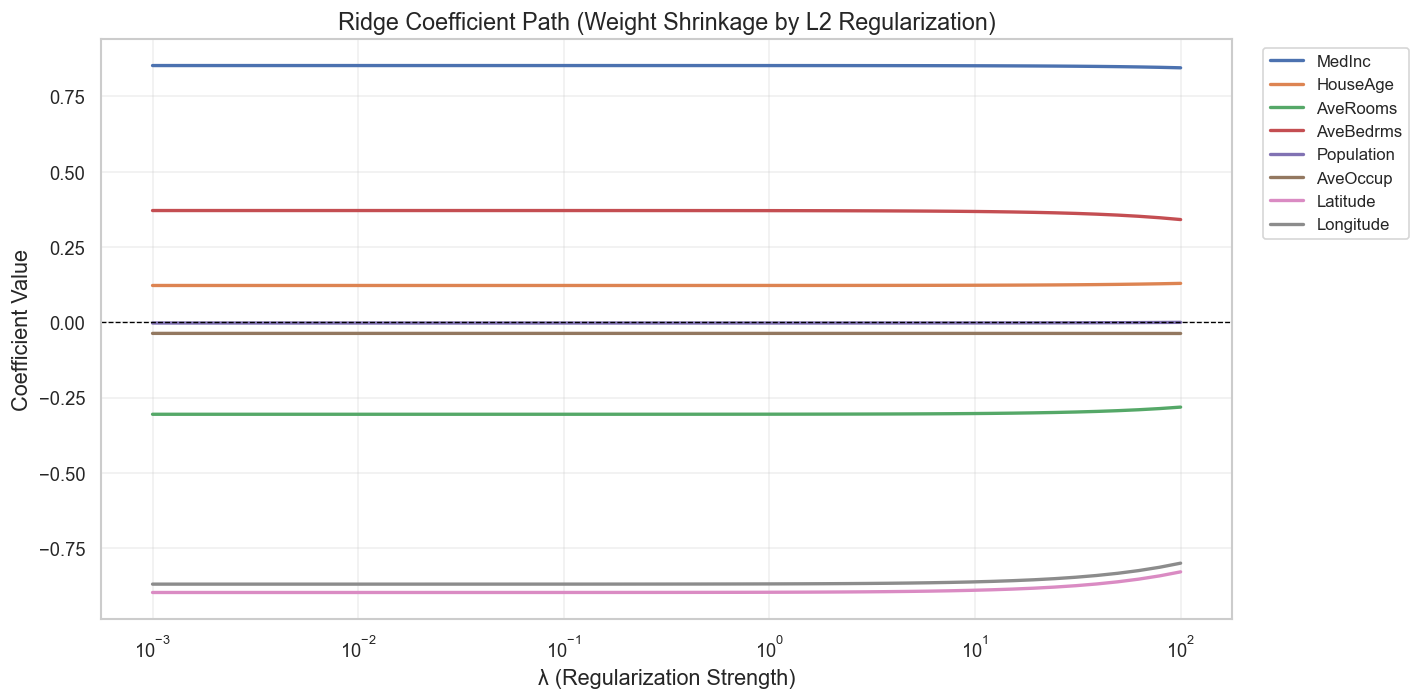

In [27]:
# ============================================================
# 可视化：随 λ 增大，各特征权重的变化
# ============================================================

lambdas_dense = np.logspace(-3, 2, 50)  # 从 0.001 到 100
coef_path = []

for lam in lambdas_dense:
    model = LinearRegression(reg_lambda=lam, method='normal_eq')
    model.fit(X_train, y_train)
    coef_path.append(model.theta[1:])  # 不含截距

coef_path = np.array(coef_path)  # shape=(50, 8)

plt.figure(figsize=(12, 6))
for i in range(len(feature_names)):
    plt.plot(lambdas_dense, coef_path[:, i], linewidth=2, label=feature_names[i])

plt.xscale('log')
plt.xlabel('λ (Regularization Strength)', fontsize=13)
plt.ylabel('Coefficient Value', fontsize=13)
plt.title('Ridge Coefficient Path (Weight Shrinkage by L2 Regularization)', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()